In [33]:
from pathlib import Path
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import tensorflow as tf
import xgboost as xgb
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, TimeDistributed, Flatten, Dropout, RepeatVector

%matplotlib inline

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path)

../data/weather_features.csv
../data/df_final.csv
../data/energy_dataset.csv


In [34]:
df_final = pd.read_csv(
    DATA_DIR / "df_final.csv",
    index_col="time",
    parse_dates=["time"]
)

In [35]:
################
# Feature Selection
################

In [36]:
# Feature Selection
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i + target_size])
        else:
            labels.append(target[i : i + target_size])

    return np.array(data), np.array(labels)

In [37]:
train_end_idx = 27048
cv_end_idx = 31056
test_end_idx = 35064

In [38]:
X = df_final[df_final.columns.drop('price actual')].values
y = df_final['price actual'].values


y = y.reshape(-1, 1)

In [39]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

In [40]:
scaler_X.fit(X[:train_end_idx])
scaler_y.fit(y[:train_end_idx])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [41]:
X_norm = scaler_X.transform(X)
y_norm = scaler_y.transform(y)

In [42]:
pca = PCA()
X_pca = pca.fit(X_norm[:train_end_idx])

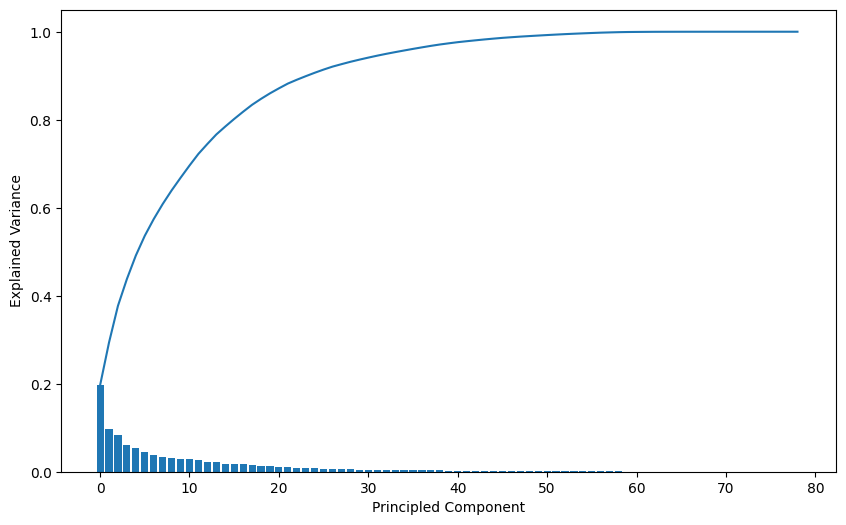

In [43]:
num_components = len(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.bar(np.arange(num_components), pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Principled Component')
plt.ylabel('Explained Variance')
plt.show()

In [44]:
pca = PCA(n_components=0.80)
pca.fit(X_norm[:train_end_idx])
X_pca = pca.transform(X_norm)

In [45]:
X_pca.shape

(35064, 16)

In [46]:
dataset_norm = np.concatenate((X_pca, y_norm), axis=1)

past_history = 24
future_target = 0

In [47]:
X_train, y_train = multivariate_data(dataset_norm, dataset_norm[:,-1],
                                     0, train_end_idx, past_history,
                                     future_target, step=1, single_step=True)

In [48]:
X_val, y_val = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                 train_end_idx, cv_end_idx, past_history, 
                                 future_target, step=1, single_step=True)

In [49]:
X_test, y_test = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                   cv_end_idx, test_end_idx, past_history, 
                                   future_target, step=1, single_step=True)

In [50]:
batch_size = 32
buffer_size = 1000

In [51]:
train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.cache().shuffle(buffer_size).batch(batch_size).prefetch(1)

validation = tf.data.Dataset.from_tensor_slices((X_val, y_val))
validation = validation.batch(batch_size).prefetch(1)

W0000 00:00:1780861574.455545    2720 cpu_allocator_impl.cc:82] Allocation of 88206336 exceeds 10% of free system memory.


In [52]:
# Define some common parameters

input_shape = X_train.shape[-2:]
loss = tf.keras.losses.MeanSquaredError()
metric = [tf.keras.metrics.RootMeanSquaredError()]
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-4 * 10**(epoch / 10))

early_stopping = tf.keras.callbacks.EarlyStopping(patience=10)


In [53]:
y_test = y_test.reshape(-1, 1)
y_test_inv = scaler_y.inverse_transform(y_test)

In [54]:
################
# Electricity Price Forecasting
################

In [55]:
def plot_model_rmse_and_loss(history):

    # Evaluate train and validation accuracies and losses

    train_rmse = history.history['root_mean_squared_error']
    val_rmse = history.history['val_root_mean_squared_error']

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Visualise epochs vs train and validation accuracies and losses

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.plot(train_rmse, label='Training RMSE')
    plt.plot(val_rmse, label='Validation RMSE')
    plt.legend()
    plt.title('Epochs vs Training and Validation RMSE')
    
    plt.subplot(1, 2, 2)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Epochs vs Training and Validation Loss')

    plt.show()                           

In [56]:
# Naive forecast
# Persistence forecast:
# predict that the next-hour price equals the most recent observed price

naive_forecast = X_test[:, -1, -1].reshape(-1, 1)

# Convert scaled predictions back into €/MWh
naive_forecast_inv = scaler_y.inverse_transform(naive_forecast)

# Calculate performance metrics
rmse_naive = np.sqrt(mean_squared_error(y_test_inv, naive_forecast_inv))
mae_naive = np.mean(np.abs(y_test_inv - naive_forecast_inv))
r2_naive = r2_score(y_test_inv, naive_forecast_inv)

print(f"Naive forecast RMSE: {rmse_naive:.3f} €/MWh")
print(f"Naive forecast MAE: {mae_naive:.3f} €/MWh")
print(f"Naive forecast R²: {r2_naive:.3f}")

Naive forecast RMSE: 3.116 €/MWh
Naive forecast MAE: 2.174 €/MWh
Naive forecast R²: 0.858


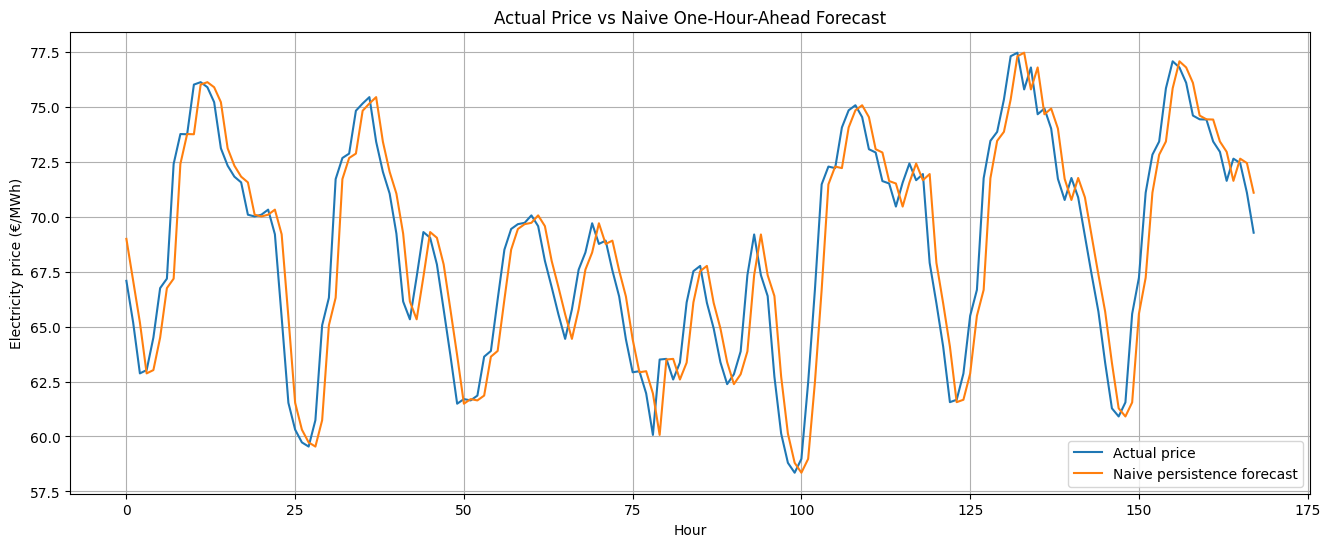

In [57]:
n_plot = 168  # First week of the test set

plt.figure(figsize=(16, 6))

plt.plot(
    y_test_inv[:n_plot],
    label="Actual price"
)

plt.plot(
    naive_forecast_inv[:n_plot],
    label="Naive persistence forecast"
)

plt.xlabel("Hour")
plt.ylabel("Electricity price (€/MWh)")
plt.title("Actual Price vs Naive One-Hour-Ahead Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [58]:
seasonal_naive_forecast = X_test[:, 0, -1].reshape(-1, 1)

seasonal_naive_forecast_inv = scaler_y.inverse_transform(
    seasonal_naive_forecast
)

rmse_seasonal_naive = np.sqrt(
    mean_squared_error(y_test_inv, seasonal_naive_forecast_inv)
)

mae_seasonal_naive = np.mean(
    np.abs(y_test_inv - seasonal_naive_forecast_inv)
)

r2_seasonal_naive = r2_score(
    y_test_inv,
    seasonal_naive_forecast_inv
)

print(f"Seasonal naive RMSE: {rmse_seasonal_naive:.3f} €/MWh")
print(f"Seasonal naive MAE: {mae_seasonal_naive:.3f} €/MWh")
print(f"Seasonal naive R²: {r2_seasonal_naive:.3f}")

Seasonal naive RMSE: 5.652 €/MWh
Seasonal naive MAE: 4.136 €/MWh
Seasonal naive R²: 0.532


In [59]:
naive_results = pd.DataFrame({
    "Model": [
        "Persistence naive",
        "24-hour seasonal naive"
    ],
    "RMSE": [
        rmse_naive,
        rmse_seasonal_naive
    ],
    "MAE": [
        mae_naive,
        mae_seasonal_naive
    ],
    "R2": [
        r2_naive,
        r2_seasonal_naive
    ]
})

naive_results

,Model,RMSE,MAE,R2
0,Persistence naive,3.116084,2.174275,0.857899
1,24-hour seasonal naive,5.652163,4.136222,0.532473


In [60]:
# XG Boost
X_train_xgb = X_train.reshape(-1, X_train.shape[1] * X_train.shape[2])
X_val_xgb = X_val.reshape(-1, X_val.shape[1] * X_val.shape[2])
X_test_xgb = X_test.reshape(-1, X_test.shape[1] * X_test.shape[2])

In [61]:
param = {'eta': 0.03, 'max_depth': 180, 
         'subsample': 1.0, 'colsample_bytree': 0.95, 
         'alpha': 0.1, 'lambda': 0.15, 'gamma': 0.1,
         'objective': 'reg:linear', 'eval_metric': 'rmse', 
         'silent': 1, 'min_child_weight': 0.1, 'n_jobs': -1}

dtrain = xgb.DMatrix(X_train_xgb, y_train)
dval = xgb.DMatrix(X_val_xgb, y_val)
dtest = xgb.DMatrix(X_test_xgb, y_test)
eval_list = [(dtrain, 'train'), (dval, 'eval')]

xgb_model = xgb.train(param, dtrain, 180, eval_list, early_stopping_rounds=3)

[0]	train-rmse:0.12945	eval-rmse:0.10910
[1]	train-rmse:0.12581	eval-rmse:0.10605
[2]	train-rmse:0.12228	eval-rmse:0.10312
[3]	train-rmse:0.11887	eval-rmse:0.10028
[4]	train-rmse:0.11556	eval-rmse:0.09751
[5]	train-rmse:0.11236	eval-rmse:0.09484
[6]	train-rmse:0.10926	eval-rmse:0.09224
[7]	train-rmse:0.10627	eval-rmse:0.08970
[8]	train-rmse:0.10336	eval-rmse:0.08726
[9]	train-rmse:0.10054	eval-rmse:0.08490
[10]	train-rmse:0.09782	eval-rmse:0.08260
[11]	train-rmse:0.09518	eval-rmse:0.08038
[12]	train-rmse:0.09263	eval-rmse:0.07827
[13]	train-rmse:0.09016	eval-rmse:0.07619
[14]	train-rmse:0.08777	eval-rmse:0.07420
[15]	train-rmse:0.08546	eval-rmse:0.07231
[16]	train-rmse:0.08323	eval-rmse:0.07048
[17]	train-rmse:0.08107	eval-rmse:0.06868
[18]	train-rmse:0.07898	eval-rmse:0.06695
[19]	train-rmse:0.07696	eval-rmse:0.06527
[20]	train-rmse:0.07500	eval-rmse:0.06366
[21]	train-rmse:0.07312	eval-rmse:0.06215
[22]	train-rmse:0.07128	eval-rmse:0.06062
[23]	train-rmse:0.06953	eval-rmse:0.05920
[2

In [62]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (27024, 24, 17)
X_val: (3984, 24, 17)
X_test: (3984, 24, 17)
y_train: (27024,)
y_val: (3984,)
y_test: (3984, 1)


In [65]:
forecast = xgb_model.predict(dtest)
xgb_forecast = forecast.reshape(-1, 1)

xgb_forecast_inv = scaler_y.inverse_transform(xgb_forecast)

rmse_xgb = np.sqrt(mean_squared_error(y_test_inv, xgb_forecast_inv))
print('RMSE of hour-ahead electricity price XGBoost forecast: {}'
      .format(round(rmse_xgb, 3)))

RMSE of hour-ahead electricity price XGBoost forecast: 2.247
